<a href="https://colab.research.google.com/github/farahiqbal321/NLP_Applied_AI/blob/main/NLP_Offensive_Language_Detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Applied AI**
## Natural Language Processing

**Farah Iqbal - S08431208**

This project focuses on detecting offensive content in social media posts, classifying tweets into three categories: Not Offensive (NOT), Targeted Insult (TIN), and Untargeted Profanity (UNT). The task involves preprocessing a labelled dataset of 13,240 tweets, followed by training machine learning models to predict labels for 460 test tweets.

The notebook covers:
- Data preprocessing and feature extraction
- Model training and evaluation using various classifiers
- Selection of the best-performing model for test predictions

Evaluation metrics, such as accuracy, will guide model selection and comparison to identify the best model for classifying offensive language.

## Importing Required Libraries

In [ ]:
# Data handling
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Text processing
import re

# Machine learning tools
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Algorithms
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
import xgboost as xgb

# SMOTE for handling imbalance
from imblearn.over_sampling import SMOTE

## Load Dataset

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

# Remove missing values
train_df = train_df.dropna()
test_df = test_df.dropna()

# Display first rows
train_df.head()

,id,tweet,label
0,86426,@USER She should ask a few native Americans wh...,UNT
1,90194,@USER @USER Go home you’re drunk!!! @USER #MAG...,TIN
2,16820,Amazon is investigating Chinese employees who ...,NOT
3,62688,"@USER Someone should'veTaken"" this piece of sh...",UNT
4,43605,@USER @USER Obama wanted liberals &amp; illega...,NOT


# Visualise Original Label Distribution

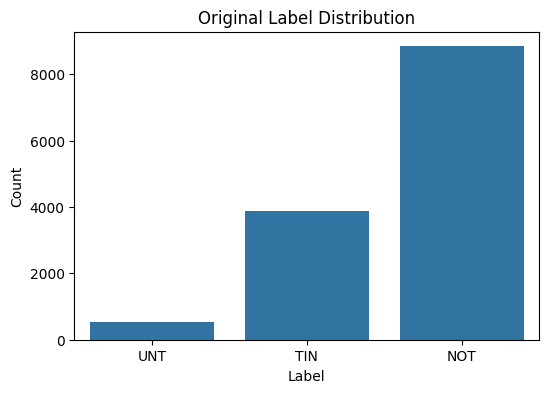

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=train_df, x="label")
plt.title("Original Label Distribution")
plt.xlabel("Label")
plt.ylabel("Count")
plt.show()

## MODEL M1

Lowercase + Punctuation Removal

Bag of Words (1-grams)

Logistic Regression

**M1 Preprocessing**

In [ ]:
def preprocess_m1(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

train_df["m1_text"] = train_df["tweet"].apply(preprocess_m1)
test_df["m1_text"] = test_df["tweet"].apply(preprocess_m1)

**M1 – Feature Extraction + SMOTE**

In [ ]:
vectorizer_m1 = CountVectorizer(ngram_range=(1,1))
X_m1 = vectorizer_m1.fit_transform(train_df["m1_text"])

encoder = LabelEncoder()
y_m1 = encoder.fit_transform(train_df["label"])

smote = SMOTE(random_state=100)
X_m1_res, y_m1_res = smote.fit_resample(X_m1, y_m1)

X_train_m1, X_val_m1, y_train_m1, y_val_m1 = train_test_split(
    X_m1_res, y_m1_res,
    test_size=0.3,
    random_state=100
)

**M1 – Train, Evaluate & Visualise**

M1 Accuracy: 0.6779788838612368
              precision    recall  f1-score   support

           0       0.76      0.65      0.70      2704
           1       0.59      0.51      0.54      2617
           2       0.68      0.88      0.77      2635

    accuracy                           0.68      7956
   macro avg       0.68      0.68      0.67      7956
weighted avg       0.68      0.68      0.67      7956



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


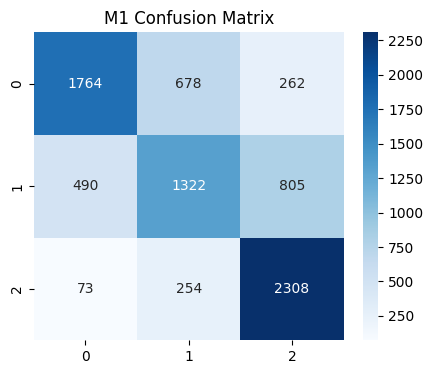

In [ ]:
model_m1 = LogisticRegression(max_iter=500)
model_m1.fit(X_train_m1, y_train_m1)

y_pred_m1 = model_m1.predict(X_val_m1)

print("M1 Accuracy:", accuracy_score(y_val_m1, y_pred_m1))
print(classification_report(y_val_m1, y_pred_m1))

cm = confusion_matrix(y_val_m1, y_pred_m1)

# Calculate Accuracy and store it for comparison
acc_m1 = accuracy_score(y_val_m1, y_pred_m1)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title("M1 Confusion Matrix")
plt.show()

## MODEL M2

Lowercase + Punctuation Removal

TF-IDF (1–2 grams)

Linear SVM

**M2 Preprocessing**

In [ ]:
def preprocess_m2(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    return text

train_df["m2_text"] = train_df["tweet"].apply(preprocess_m2)

**M2 – Feature Extraction + SMOTE**

In [ ]:
vectorizer_m2 = TfidfVectorizer(ngram_range=(1,2))
X_m2 = vectorizer_m2.fit_transform(train_df["m2_text"])
y_m2 = encoder.transform(train_df["label"])

X_m2_res, y_m2_res = smote.fit_resample(X_m2, y_m2)

X_train_m2, X_val_m2, y_train_m2, y_val_m2 = train_test_split(
    X_m2_res, y_m2_res,
    test_size=0.3,
    random_state=100
)

**M2 – Train & Evaluate**

In [ ]:
model_m2 = LinearSVC()
model_m2.fit(X_train_m2, y_train_m2)

y_pred_m2 = model_m2.predict(X_val_m2)

# Calculate Accuracy and store it for comparison
acc_m2 = accuracy_score(y_val_m2, y_pred_m2)

print("M2 Accuracy:", accuracy_score(y_val_m2, y_pred_m2))
print(classification_report(y_val_m2, y_pred_m2))

M2 Accuracy: 0.9155354449472096
              precision    recall  f1-score   support

           0       0.90      0.86      0.88      2704
           1       0.86      0.89      0.88      2617
           2       0.98      1.00      0.99      2635

    accuracy                           0.92      7956
   macro avg       0.92      0.92      0.92      7956
weighted avg       0.92      0.92      0.92      7956



## MODEL M3

Lowercase + Punctuation Removal

TF-IDF (1-grams)

Naive Bayes

**M3 Preprocessing**

In [ ]:
train_df["m3_text"] = train_df["tweet"].apply(preprocess_m1)

**M3 – Feature Extraction + SMOTE**

In [ ]:
vectorizer_m3 = TfidfVectorizer(ngram_range=(1,1))
X_m3 = vectorizer_m3.fit_transform(train_df["m3_text"])
y_m3 = encoder.transform(train_df["label"])

X_m3_res, y_m3_res = smote.fit_resample(X_m3, y_m3)

X_train_m3, X_val_m3, y_train_m3, y_val_m3 = train_test_split(
    X_m3_res, y_m3_res,
    test_size=0.3,
    random_state=100
)

**M3 – Train & Evaluate**

In [ ]:
model_m3 = MultinomialNB()
model_m3.fit(X_train_m3, y_train_m3)

y_pred_m3 = model_m3.predict(X_val_m3)

# Calculate Accuracy and store it for comparison
acc_m3 = accuracy_score(y_val_m3, y_pred_m3)

print("M3 Accuracy:", accuracy_score(y_val_m3, y_pred_m3))
print(classification_report(y_val_m3, y_pred_m3))

M3 Accuracy: 0.779788838612368
              precision    recall  f1-score   support

           0       0.86      0.55      0.67      2704
           1       0.70      0.81      0.75      2617
           2       0.81      0.99      0.89      2635

    accuracy                           0.78      7956
   macro avg       0.79      0.78      0.77      7956
weighted avg       0.79      0.78      0.77      7956



## MODEL M4

Decision Tree

**M4 – Feature Extraction + SMOTE**

In [ ]:
X_m4 = vectorizer_m1.transform(train_df["m1_text"])
y_m4 = encoder.transform(train_df["label"])

X_m4_res, y_m4_res = smote.fit_resample(X_m4, y_m4)

X_train_m4, X_val_m4, y_train_m4, y_val_m4 = train_test_split(
    X_m4_res, y_m4_res,
    test_size=0.3,
    random_state=100
)

**M4 – Train & Evaluate**

In [ ]:
model_m4 = DecisionTreeClassifier()
model_m4.fit(X_train_m4, y_train_m4)

y_pred_m4 = model_m4.predict(X_val_m4)

# Calculate Accuracy and store it for comparison
acc_m4 = accuracy_score(y_val_m4, y_pred_m4)

print("M4 Accuracy:", accuracy_score(y_val_m4, y_pred_m4))
print(classification_report(y_val_m4, y_pred_m4))

M4 Accuracy: 0.6714429361488184
              precision    recall  f1-score   support

           0       0.70      0.53      0.60      2704
           1       0.58      0.59      0.58      2617
           2       0.73      0.89      0.81      2635

    accuracy                           0.67      7956
   macro avg       0.67      0.67      0.66      7956
weighted avg       0.67      0.67      0.66      7956



## MODEL M5

K-Nearest Neighbours

**M5 – Train & Evaluate**

M5 Accuracy: 0.5314228255404726
              precision    recall  f1-score   support

           0       0.85      0.04      0.07      2704
           1       0.49      0.64      0.56      2617
           2       0.55      0.93      0.69      2635

    accuracy                           0.53      7956
   macro avg       0.63      0.54      0.44      7956
weighted avg       0.63      0.53      0.44      7956



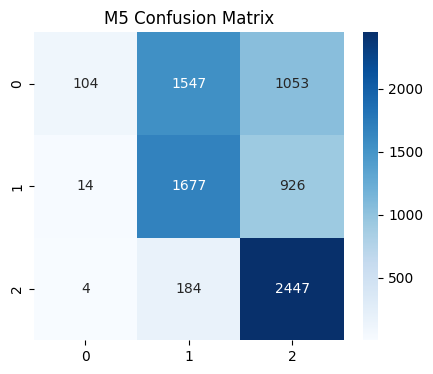

In [ ]:
model_m5 = KNeighborsClassifier(n_neighbors=5)

# Train using same training split as M4
model_m5.fit(X_train_m4, y_train_m4)

# Predict on validation set
y_pred_m5 = model_m5.predict(X_val_m4)

# Evaluate using same validation labels
print("M5 Accuracy:", accuracy_score(y_val_m4, y_pred_m5))
print(classification_report(y_val_m4, y_pred_m5))

# Confusion matrix
cm_m5 = confusion_matrix(y_val_m4, y_pred_m5)

# Calculate Accuracy and store it for comparison
acc_m5 = accuracy_score(y_val_m4, y_pred_m5)

plt.figure(figsize=(5,4))
sns.heatmap(cm_m5, annot=True, fmt="d", cmap="Blues")
plt.title("M5 Confusion Matrix")
plt.show()

## MODEL M6

XGBoost

**M6 – Train & Evaluate**

M6 Accuracy: 0.8533182503770739
              precision    recall  f1-score   support

           0       0.76      0.96      0.85      2704
           1       0.91      0.65      0.76      2617
           2       0.93      0.95      0.94      2635

    accuracy                           0.85      7956
   macro avg       0.87      0.85      0.85      7956
weighted avg       0.87      0.85      0.85      7956



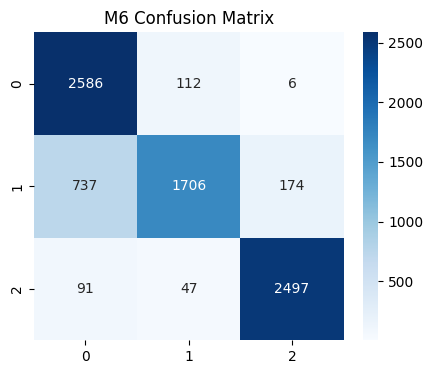

In [ ]:
# Create XGBoost model
model_m6 = xgb.XGBClassifier(
    eval_metric='mlogloss',   # Proper metric for multiclass
    random_state=100
)

# Train using same split as M4
model_m6.fit(X_train_m4, y_train_m4)

# Predict
y_pred_m6 = model_m6.predict(X_val_m4)

# Evaluate using correct validation labels
print("M6 Accuracy:", accuracy_score(y_val_m4, y_pred_m6))
print(classification_report(y_val_m4, y_pred_m6))

# Confusion Matrix
cm_m6 = confusion_matrix(y_val_m4, y_pred_m6)

# Calculate Accuracy and store it for comparison
acc_m6 = accuracy_score(y_val_m4, y_pred_m6)

plt.figure(figsize=(5,4))
sns.heatmap(cm_m6, annot=True, fmt="d", cmap="Blues")
plt.title("M6 Confusion Matrix")
plt.show()

## Model Comparison Table

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Store model results
results = {
    "Model": [
        "M1 - Logistic Regression (BoW 1-gram)",
        "M2 - Linear SVM (TF-IDF 1-2 grams)",
        "M3 - Naive Bayes (TF-IDF 1-gram)",
        "M4 - Decision Tree (BoW)",
        "M5 - KNN (BoW)",
        "M6 - XGBoost (BoW)"
    ],
    "Accuracy": [
        acc_m1,
        acc_m2,
        acc_m3,
        acc_m4,
        acc_m5,
        acc_m6
    ]
}

# Create DataFrame
results_df = pd.DataFrame(results)

# Sort descending
results_df = results_df.sort_values(by="Accuracy", ascending=False)

# Display styled table with best accuracy highlighted
results_df.style.highlight_max(subset=["Accuracy"], color="lightgreen")

,Model,Accuracy
1,M2 - Linear SVM (TF-IDF 1-2 grams),0.915535
5,M6 - XGBoost (BoW),0.853318
2,M3 - Naive Bayes (TF-IDF 1-gram),0.779789
0,M1 - Logistic Regression (BoW 1-gram),0.677979
3,M4 - Decision Tree (BoW),0.671443
4,M5 - KNN (BoW),0.531423


## Model Comparison Bar Chart

/tmp/ipython-input-632/3439742063.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x="Accuracy", y="Model", palette=palette)


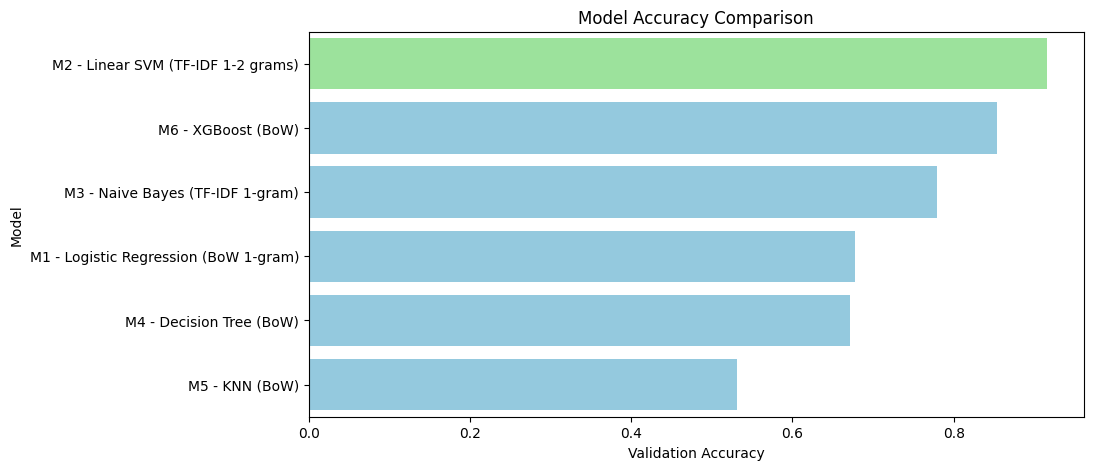

In [ ]:
# Bar chart with best model highlighted
plt.figure(figsize=(10,5))
palette = ["lightgreen" if acc == results_df["Accuracy"].max() else "skyblue" for acc in results_df["Accuracy"]]
sns.barplot(data=results_df, x="Accuracy", y="Model", palette=palette)
plt.title("Model Accuracy Comparison")
plt.xlabel("Validation Accuracy")
plt.ylabel("Model")
plt.show()

## Final Test Predictions

Chosen Model is Model M2 as this has the highest accuracy at 92%.

In [ ]:
df_test = pd.read_csv("test.csv")

# Apply M2 preprocessing
df_test["processed"] = df_test["tweet"].apply(preprocess_m2)

# Transform text using M2 vectorizer
X_test = vectorizer_m2.transform(df_test["processed"])

# Predict using best model
predictions = model_m2.predict(X_test)

# Convert encoded labels back to original class names
df_test["prediction"] = encoder.inverse_transform(predictions)

# Save predictions to CSV file
df_test[["id", "prediction"]].to_csv("test-predictions.csv", index=False)

print("Test predictions saved successfully.")

Test predictions saved successfully.


## Predicted Label Distribution (Test Set)

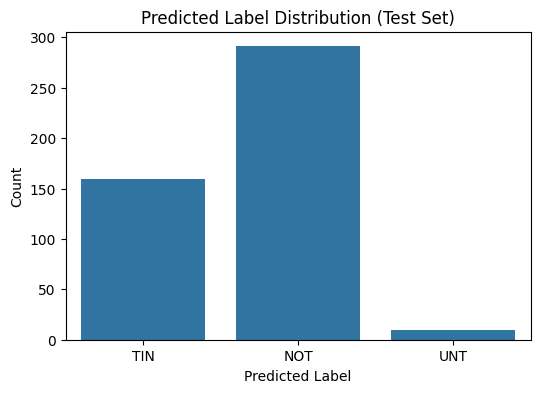

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df_test, x="prediction")
plt.title("Predicted Label Distribution (Test Set)")
plt.xlabel("Predicted Label")
plt.ylabel("Count")
plt.show()

## Final Summary

In this project, six machine learning models were trained and evaluated to classify offensive language in tweets. Model M2 (Linear SVM with TF-IDF features) achieved the highest validation accuracy and was selected for final deployment.

The final predictions were generated on the test dataset and saved for submission. Analysis of the predicted label distribution highlights the model's behaviour on unseen data, while the comparison table and bar chart clearly show M2 as the top-performing model. This workflow demonstrates a complete NLP pipeline, including data preprocessing, feature extraction, model training, evaluation, and deployment.